# Follow the Money - How EU Research Agenda Influences the Future of Society (v3)

### INSTRUCTIONS
Complete instructions on this [doc](https://pad.liiib.re/rXXeznogTyuTG2tfKYqfSA?view)
#### STEP 1) Choose a company from the [Super list](https://github.com/sciences-citoyennes/Future-Earth-Workshop/blob/main/Super%20List%20pdf.pdf)
   - The rest of the code will anaylse the top French projects that this company particpated in
   - You can pick multiple companies at once but the code will combine the results and not all steps distinguish between each company in the totals

#### STEP 2) Choose the Framework Programs to analyze:
   - 1 = Horizon Europe (2021 - 2027)
   - 2 = Horizon 2020 (2014 - 2020)
   - 3 = FP7 (2007 - 2013)
   - 4 = FP6 (2002 - 2006), note: this dataset is messy and has missing information which may skew the results

#### OPTIONAL STEP) Choose Keywords from the European Science Vocabulary [(EuroSciVoc) List](https://op.europa.eu/en/web/eu-vocabularies/concept-scheme/-/resource?uri=http://data.europa.eu/8mn/euroscivoc/40c0f173-baa3-48a3-9fe6-d6e8fb366a00).
- *Note: go to table or list view to browse through them.*
- This will count how many times those keywords are used to describe the projects that the chosen company is a part of
- You can leave this list empty and it will plot all of the keywords in all of the projects
  
### STEP 5) Fill Out Choices In Cell Below


In [1]:
###### do not edit the imports ######
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
#####################################

# STEP 1) Replace AIRBUS with chosen company name in CAPITAL LETTERS (can pick multiple companies but picking a single one first is suggested)
Entreprises = ['AIRBUS']

Prog = {1: 'HORIZON', 2: 'H2020', 3: 'FP7'} #(4: 'FP6') excluding FP6 from the workshop because it is messy and has missing information

# STEP 2) Type the number followed by a comma for each of the Framework Programs you chose, for example: IncludeProgrammes = [1,2,3]
IncludeProgrammes = [1,2,3]

#OPTIONAL) type a few keywords from the official EuroSciVoc list, for example KeyWords = ['artificial intelligence','energy and fuels']
#   Leaving this blank will plot all of the keywords used to describe the project
KeyWords = []

##################### N top project #####################
Ntop_TotFunds = 3 # The N largest projects to show

##################### N top keywords #####################
Nkw = 15 #  Number of most popular keywords to show -- if the list is empty 


### (Hidden) Filter data to find the total funding and the top funded projects

In [2]:

## use this one when accessing the data file from GitHub -- ie when using BINDER link
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(CleanFolderName + Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))


'''
## use this one when accessing the data file stored on your computer

#replace with the file path on your computer
CleanFolderName = '/Users/annalewicki/Nextcloud/Programmes/1-Réorienter la recherche/Politique de la recherche/Future Earth/'
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(CleanFolderName + Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))
'''


In [3]:
############# DO NOT EDIT ##############

### Find projects that chosen company is a part of from Clean Data (EU Fundings-TopFRcomp)

Entreprises = [x.upper() for x in Entreprises] # Put names all in capital letters 

if Entreprises != []: 
    IncludeTable = EUfullTable[['projectAcronym','Company']].groupby('projectAcronym').max()
    IncludeGroupIndex = IncludeTable['Company'].apply(lambda x: x in Entreprises)
    IncludeAc = set(IncludeTable['Company'].loc[IncludeGroupIndex].keys())
    IncludeIndex = EUfullTable['projectAcronym'].apply(lambda x: x in IncludeAc)
    
    EUfullTable = EUfullTable.loc[IncludeIndex]
else: 
    print(' ')
    print('COMPANY LIST EMPTY ! STATS ARE SHOWN FOR FULL LIST !')

##################### REPAIR netEcContribution #####################

def RepairNetC(x): 
    try:
        float(x)
        return float(x)
    except ValueError:
        return 0

EUfullTable.loc[:,'netEcContribution'] = EUfullTable['netEcContribution'].apply(RepairNetC)

##################### EXTRACT SERIES #####################

AcSeries = EUfullTable['projectAcronym']
SDateSeries = EUfullTable['Start Date']
Nt = AcSeries.size # Total line number 

# EUcompTable = EUfullTable.loc[EUfullTable['Company'] != '-'] # SUM OVER ALL PRIVATE COMPANIES OF SAID PROJECT

EUcompIndex = EUfullTable['Company'].apply(lambda x: x in Entreprises) 
EUcompTable = EUfullTable.loc[EUcompIndex] # Select only lines with chosen companies 


In [4]:
############# DO NOT EDIT ##############

### Calculate the Total Funding Company Receives and Top 3 Funded Projects

##################### NUMBER OF PROJECTS PER PROGRAMME #####################


TotalNum_Prog = EUfullTable[['projectAcronym','source']].groupby('projectAcronym').max().reset_index()
TotalNum_Prog = TotalNum_Prog['source'].value_counts()
TotalNum_Prog = TotalNum_Prog.rename(index = Prog) 
TotalNum_Prog['Nombre total'] = np.sum(TotalNum_Prog)
TotalNum_ProgR = TotalNum_Prog[::-1] # Reverse order 


##################### FUNDINGS (brut) GIVEN TO COMPANIES PER PROGRAMME #####################
'''
#CODE V3 but the sum is 0, trying to undersand why 
TotalFunds_Prog = EUcompTable[['ecContribution','source']].groupby('source',group_keys=False).sum()
TotalFunds_Prog = TotalFunds_Prog['ecContribution'].rename_axis(None, axis=0) 
TotalFunds_Prog = TotalFunds_Prog.rename(index = Prog).apply(lambda x: np.round(x/1e6)) # In Millions euros
TotalFunds_Prog['Somme total'] = np.sum(TotalFunds_Prog)
TotalFunds_ProgR = TotalFunds_Prog[::-1] # Reverse order


'''
#OLD CODE FROM VERSION 2
TotalFunds_Prog = EUfullTable[['ecContribution','source']].groupby('source',group_keys=False).sum()
TotalFunds_Prog = TotalFunds_Prog['ecContribution'].rename_axis(None, axis=0) 
TotalFunds_Prog = TotalFunds_Prog.rename(index = Prog).apply(lambda x: np.round(x/1e6)) # In Millions euros
TotalFunds_Prog['Somme total'] = np.sum(TotalFunds_Prog)
TotalFunds_ProgR = TotalFunds_Prog[::-1] # Reverse order



##################### TOTAL FUNDINGS (brut) PER PROJECT #####################


Project_TotFunds = EUfullTable[['projectAcronym','Title','ecContribution','EuroSciVoc','Free Keywords']].groupby('projectAcronym').sum().reset_index()
Project_TotFunds['EuroSciVoc'] = Project_TotFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_TotFunds = Project_TotFunds.sort_values('ecContribution',ascending=False) 
Project_TotFunds['ecContribution'] = Project_TotFunds['ecContribution'].apply(lambda x: x/1e6)

Top3Project_TotFunds = Project_TotFunds.iloc[0:Ntop_TotFunds]


##################### FUNDINGS (net) GIVEN TO COMPANIES PER PROJECT #####################

Project_GivenFunds = EUcompTable[['projectAcronym','Title','netEcContribution','EuroSciVoc']].groupby('projectAcronym').sum().reset_index()
Project_GivenFunds['EuroSciVoc'] = Project_GivenFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_GivenFunds = Project_GivenFunds.sort_values('netEcContribution',ascending=False) 
Project_GivenFunds['netEcContribution'] = Project_GivenFunds['netEcContribution'].apply(lambda x: x/1e6)

Top3Project_GivenFunds = Project_GivenFunds.iloc[0:Ntop_TotFunds]



# Main Info
#### STEP 6) Run the code by clicking on 'Run' in the menu bar and selecting 'Run All Cells'.
This will run the entire code all at once and all you have to do is scroll through to find the information you need. **Remember to Run All Cells every time you change your selections in step 5**


#### STEP 7) Fill out Worksheet Using Outputed Info Below
From the printed results of Main Info start filling in the Worksheet below (Company name, the total sum of money recieved over selected programs, and the top project acronym and title)

**Note: For 'Top projects' the first column is just the number of the row in the data sheet, ignore it!**

In [17]:
############# DO NOT EDIT ##############
print(' ')
print(Entreprises[0]+' RECEIVES:')
print('Projects '+Entreprises[0]+' receives the most public money from:')
print(Top3Project_GivenFunds)

print('----------------------------------------------------------------------------------------------------------------')

print(' ')
print('PROJECT RECEIVES:')
print('Projects that '+Entreprises[0]+' is a part of that receive the most funding')
print(Top3Project_TotFunds)
print('----------------------------------------------------------------------------------------------------------------')

print(' ')
print('Number of projects:')
print(TotalNum_Prog)

print('----------------------------------------------------------------------------------------------------------------')
print(' ')
print('WARNING This is the sum of EU money given to all the PROJECTS that the company is a part of, not the total money given to the company')
print('(The sum of money given to the company will be included soon)')
print('Total Sum (in M €):')
print(TotalFunds_Prog)

 
AIRBUS RECEIVES:
Projects AIRBUS receives the most public money from:
    projectAcronym  \
107   FRC GAM 2018   
58       COMPANION   
252        UNIFIED   

                                                                               Title  \
107                                    Fast RotorcraftFast RotorcraftFast Rotorcraft   
58   COMmon Platform and Advanced INstrumentation ReadIness for ultra efficient p...   
252  Ultra Novel and Innovative Fully Integrated Engine DemonstrationsUltra Novel...   

     netEcContribution  \
107          36.625779   
58           13.410774   
252          10.478125   

                                                                          EuroSciVoc  
107  [aeronautical engineering, rotorcraft, energy and fuels, climatic change mit...  
58                                                          [aircraft, liquid fuels]  
252                                                     [aircraft, energy and fuels]  
---------------------------------

### Step 8) Explore the graphs outputted in the next sections

### Plot Set up

In [6]:
Font = 12
plt.rc('text', usetex=False) # FORCE NO LATEX
plt.rc('font',size=Font)
plt.rc('font',family='serif')

## Plot : AMOUNT OF MONEY COMPANY REVIECED AS PART OF TOP PROJECTS

Text(0.5, 0, 'M €')

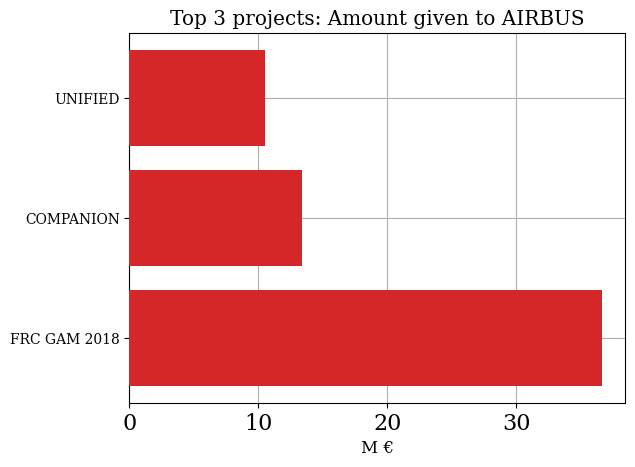

In [7]:
#####################
# Top 3 projects: given funds 
##################### 

plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_GivenFunds['projectAcronym'],Top3Project_GivenFunds['netEcContribution'],color = 'tab:red',zorder=3) 
plt.grid()
if len(Entreprises) == 1: 
    plt.title('Top '+str(Ntop_TotFunds)+' projects: Amount given to '+Entreprises[0])
else: 
    plt.title('Top '+str(Ntop_TotFunds)+' projets: Amount given')
plt.xlabel('M €')

# Projects that carrefoure received the most public money from

## Plot: TOP PROJECTS GIVEN THE MOST FUNDING

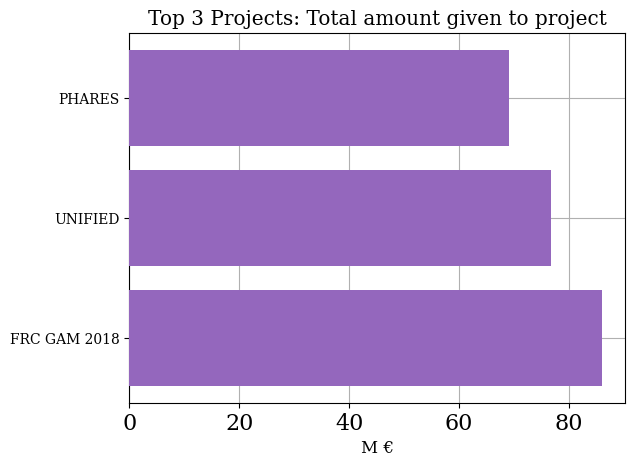

WARNING This plot ranks the projects that the company is a part of by total EU contribution, it is not ranked by how much the company receives through the project
(The ranking of the projects by amount of money given to the company will be included soon)


In [21]:
"""
#####################
# Top 3 projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_TotFunds['projectAcronym'],Top3Project_TotFunds['ecContribution'],color = 'tab:purple',zorder=3) 
plt.grid()
plt.title('Top '+str(Ntop_TotFunds)+' Projects: Total amount given to project')
plt.xlabel('M €')
plt.show()
print('WARNING This plot ranks the projects that the company is a part of by total EU contribution, it is not ranked by how much the company receives through the project')
print('(The ranking of the projects by amount of money given to the company will be included soon)')



## Plot: NUMBER OF PROJECTS PER PROGRAMME

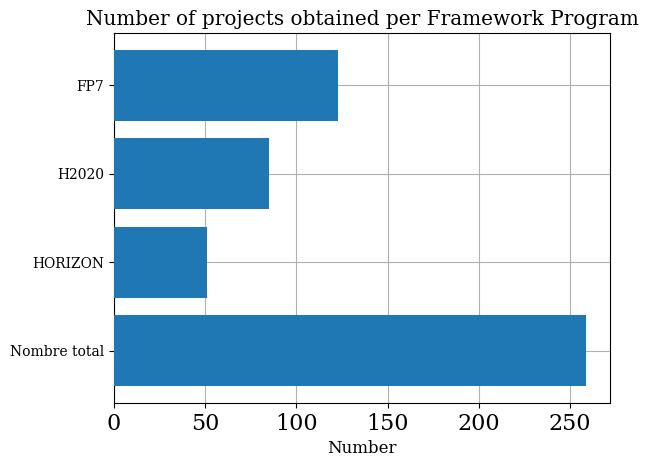

In [9]:
"""
#####################
# Comp. number of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalNum_ProgR.index,TotalNum_ProgR,color = 'tab:blue',zorder=3) 
plt.grid()
plt.title('Number of projects obtained per Framework Program')
plt.xlabel('Number')
plt.show()

## Plot: Sum total obtained per Framework Program

### WARNING This plot still uses ecContribution so its the sum of money over all the PROJECTS that the company is a part of during a framework and not the sum of money that the company recieves over the framework program

Text(0.5, 0, 'M €')

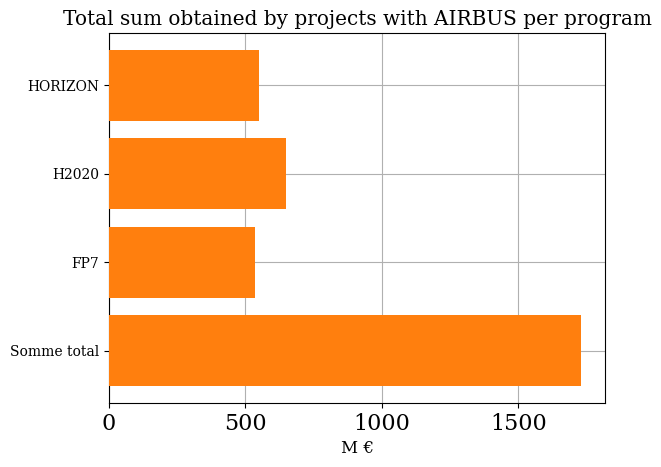

In [22]:
##### this still uses ecContribution so its the sum of money over all the projects that company is a part of 
##### and not the money that the company recieves over the programs

plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalFunds_ProgR.index,TotalFunds_ProgR,color = 'tab:orange',zorder=3) 
plt.grid()
if len(Entreprises) == 1: 
    #plt.title('Total sum obtained by '+Entreprises[0]+' per program')
    plt.title('Total sum obtained by projects with '+Entreprises[0]+' per program')
else: 
    plt.title("Total sum obtained by the group of companies per program")
plt.xlabel('M €') 

## KEYWORDS STATS 

This plot collects the keywords over all of the projects of the chosen company and counts how many times they were used. It will either plot all of the keywords or only the chosen ones you typed in the first step.

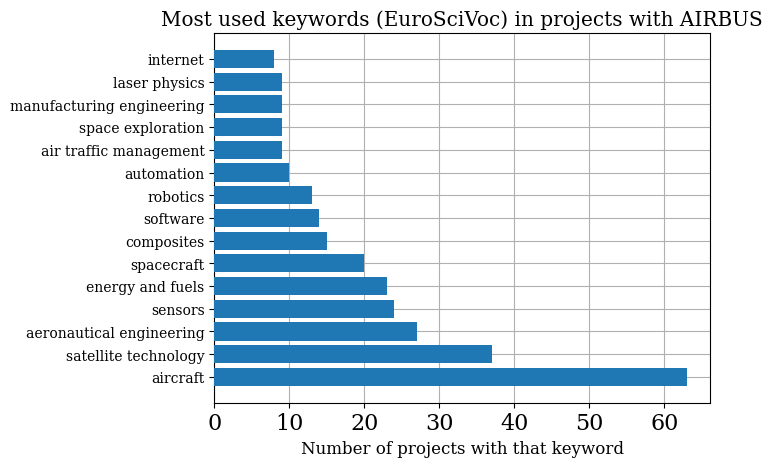

In [11]:
KeyWords_Nlist = list(EUfullTable.drop_duplicates(subset=['projectAcronym'])['EuroSciVoc']) # gives a nested list 
KeyWords_list = [item for sublist in KeyWords_Nlist for item in sublist] # Flatten the nested list 
KeyWords_set = set(KeyWords_list)

KeyWords_Count = pd.Series(KeyWords_list).value_counts() 

KeyWords_RCount = KeyWords_Count.iloc[0:Nkw] 

if len(KeyWords) > 0: 
    for jk in KeyWords: 
        if jk not in KeyWords_set: 
            print(' ')
            print('Keyword "'+jk+'" not in the standard EuroSciVoc list! Has been removed.')
            KeyWords.remove(jk) 
    KeyWords_selected_index = pd.Series(KeyWords_Count.index).apply(lambda x: x in KeyWords)
    KeyWords_selected_index.index = KeyWords_Count.index 
    KeyWords_selected = KeyWords_Count.loc[KeyWords_selected_index] 

"""
#####################
#   Keywords count 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
if len(KeyWords)>0: 
    plt.figure() 
    plt.barh(KeyWords_selected.index,KeyWords_selected,zorder=3) 
    plt.grid()
    plt.title('Occurences of chosen keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')
else: 
    plt.figure() 
    plt.barh(KeyWords_RCount.index,KeyWords_RCount,zorder=3) 
    plt.grid()
    if len(Entreprises) == 1: 
        plt.title('Most used keywords (EuroSciVoc) in projects with '+Entreprises[0]) 
    else: 
        plt.title('Most used keywords (EuroSciVoc) in projects with chosen companies') 
    plt.xlabel('Number of projects with that keyword')

plt.show()